In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harishkumardatalab/food-image-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'food-image-classification-dataset' dataset.
Path to dataset files: /kaggle/input/food-image-classification-dataset


In [ ]:
import os

# Check dataset folder structure
# Note: kagglehub usually downloads to a root folder; we need to find the directory containing image classes
def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        if len(files) > 0:
            print(f'{subindent}{len(files)} files found.')
        if level >= 2: break # Only view basic structure

list_files(path)

food-image-classification-dataset/
    Food Classification dataset/
        momos/
            323 files found.


In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# Fix: Point to the actual directory containing the food categories
dataset_root = os.path.join(path, "Food Classification dataset")

all_images = []
all_labels = []

# Iterate through subdirectories (each directory is a label/food category)
if os.path.exists(dataset_root):
    for category in os.listdir(dataset_root):
        category_path = os.path.join(dataset_root, category)
        if os.path.isdir(category_path):
            for img_name in os.listdir(category_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_images.append(os.path.join(category_path, img_name))
                    all_labels.append(category)

# Check if data was found
if len(all_images) == 0:
    print("Error: No images found. Please check the directory structure.")
else:
    # Create a DataFrame for easier management
    df = pd.DataFrame({'image_path': all_images, 'label': all_labels})

    # Split the dataset into 80% Train and 20% Test
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=df['label']
    )

    print(f"Total images found: {len(df)}")
    print(f"Number of images in Train set: {len(train_df)}")
    print(f"Number of images in Test set: {len(test_df)}")

    # Display the first 5 rows of the Train set
    display(train_df.head())

Total images found: 23873
Number of images in Train set: 19098
Number of images in Test set: 4775


,image_path,label
8849,/kaggle/input/food-image-classification-datase...,Crispy Chicken
8679,/kaggle/input/food-image-classification-datase...,Crispy Chicken
4864,/kaggle/input/food-image-classification-datase...,Hot Dog
17608,/kaggle/input/food-image-classification-datase...,Taco
17731,/kaggle/input/food-image-classification-datase...,Taco


### GPU Check
First, let's check if a GPU is available and configured for TensorFlow.

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU found: {gpus}")
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU found. Training will run on CPU, which might be slow.")

# You can also run a shell command to check GPU status (if nvidia-smi is available)
import os
if os.system('nvidia-smi') != 0:
    print("nvidia-smi command not found or failed.")

GPU found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
1 Physical GPUs, 1 Logical GPUs


### Inception Model Building and Training
Now, let's build an InceptionV3 model, fine-tune it with our dataset, and train it.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

IMG_SIZE = (224, 224) # InceptionV3 expects at least 75x75, 224x224 is common
BATCH_SIZE = 32
EPOCHS = 10 # You can adjust this number

# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Get the number of unique classes
num_classes = len(df['label'].unique())
print(f"Number of classes: {num_classes}")

# Create data generators
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Load InceptionV3 pre-trained on ImageNet
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Add custom layers for our classification task
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the layers of the pre-trained model
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

print("Starting model training...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)
print("Model training completed.")

Number of classes: 34
Found 19098 validated image filenames belonging to 34 classes.
Found 4775 validated image filenames belonging to 34 classes.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 23,935,810 (91.31 MB)

 Trainable params: 2,133,026 (8.14 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Starting model training...
Epoch 1/10
104/597 ━━━━━━━━━━━━━━━━━━━━ 4:37 564ms/step - accuracy: 0.2718 - loss: 3.1500

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


597/597 ━━━━━━━━━━━━━━━━━━━━ 428s 687ms/step - accuracy: 0.5442 - loss: 1.6127 - val_accuracy: 0.6752 - val_loss: 1.0964
Epoch 2/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 343s 574ms/step - accuracy: 0.6473 - loss: 1.1886 - val_accuracy: 0.6735 - val_loss: 1.0827
Epoch 3/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 347s 581ms/step - accuracy: 0.6743 - loss: 1.0801 - val_accuracy: 0.7062 - val_loss: 0.9782
Epoch 4/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 350s 587ms/step - accuracy: 0.6939 - loss: 1.0133 - val_accuracy: 0.7009 - val_loss: 1.0044
Epoch 5/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 344s 576ms/step - accuracy: 0.7042 - loss: 0.9805 - val_accuracy: 0.7162 - val_loss: 0.9482
Epoch 6/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 344s 576ms/step - accuracy: 0.7121 - loss: 0.9375 - val_accuracy: 0.7317 - val_loss: 0.8736
Epoch 7/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 350s 586ms/step - accuracy: 0.7183 - loss: 0.9213 - val_accuracy: 0.7259 - val_loss: 0.9298
Epoch 8/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 346s 580ms/step - accuracy: 0.7298 - loss: 0.88

### Training Results Summary
Let's check the final accuracy and loss from the training process.

In [ ]:
import numpy as np

# Evaluate the model on the test set
loss, accuracy = model.evaluate(test_generator)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Get the best validation accuracy from history
best_val_accuracy = np.max(history.history['val_accuracy'])
print(f"Best Validation Accuracy during training: {best_val_accuracy:.4f}")

best_val_loss = np.min(history.history['val_loss'])
print(f"Best Validation Loss during training: {best_val_loss:.4f}")

150/150 ━━━━━━━━━━━━━━━━━━━━ 28s 184ms/step - accuracy: 0.7317 - loss: 0.8736

Test Loss: 0.8736
Test Accuracy: 0.7317
Best Validation Accuracy during training: 0.7399
Best Validation Loss during training: 0.8736


### Training Plots
Visualize the training and validation accuracy and loss over epochs.

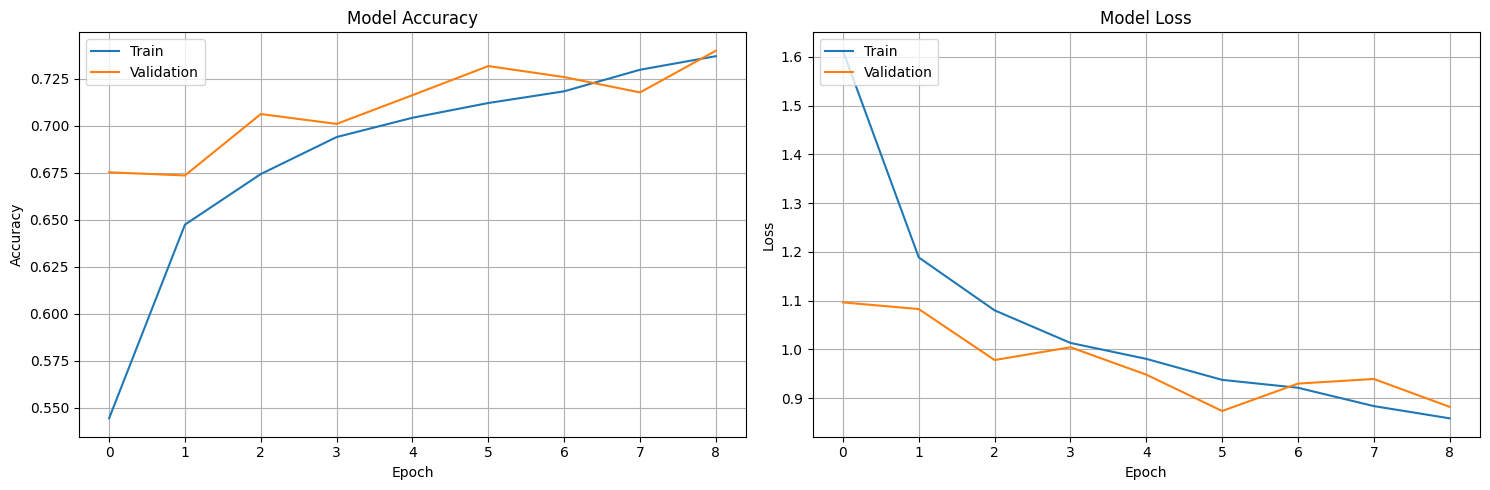

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Validation'], loc='upper left')
ax1.grid(True)

# Plot training & validation loss values
ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Validation'], loc='upper left')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'ModelTraining'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Assuming `fig` is the last created matplotlib figure
# upload_plt_to_gcs(num_fig, step, fig) # Uncomment and define `upload_plt_to_gcs` if needed